# Finding Correlations

This is my own practice notebook based on what I learned in the IBM Data Analyst Capstone Project on Coursera.

## Objective

This notebook practices exploratory data analysis for correlation analysis. It loads the survey dataset, checks compensation distribution, compares compensation by country, removes compensation outliers, and visualizes relationships between key variables.

## Step 1: Install and import required libraries

In [1]:
# Import the libraries needed for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the dataset

In [6]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Step 3: Analyze and visualize compensation distribution

Plot the distribution of `ConvertedCompYearly` to examine the spread of yearly compensation.

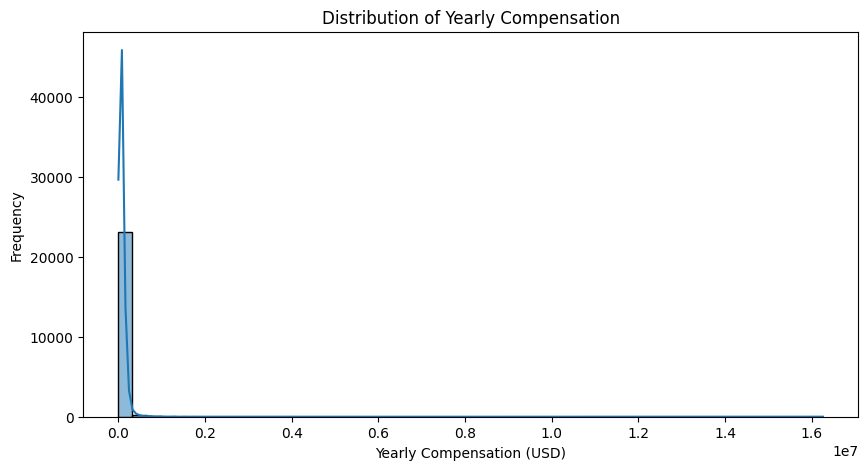

In [7]:
# Create a histogram to show the distribution of yearly compensation
plt.figure(figsize=(10, 5))
sns.histplot(df['ConvertedCompYearly'], bins=50, kde=True)

# Add chart title and axis labels
plt.title('Distribution of Yearly Compensation')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Frequency')

# Display the chart
plt.show()

## Step 4: Calculate median compensation for full-time employees

Filter full-time employees and calculate their median yearly compensation.

In [8]:
# Filter the dataset for respondents who are employed full-time
full_time = df[df['Employment'] == 'Employed, full-time']

# Calculate the median yearly compensation for full-time employees
median_full_time = full_time['ConvertedCompYearly'].median()

# Display the result
median_full_time

np.float64(69814.0)

## Step 5: Analyze compensation range and distribution by country

Use a box plot to compare yearly compensation distributions across countries.

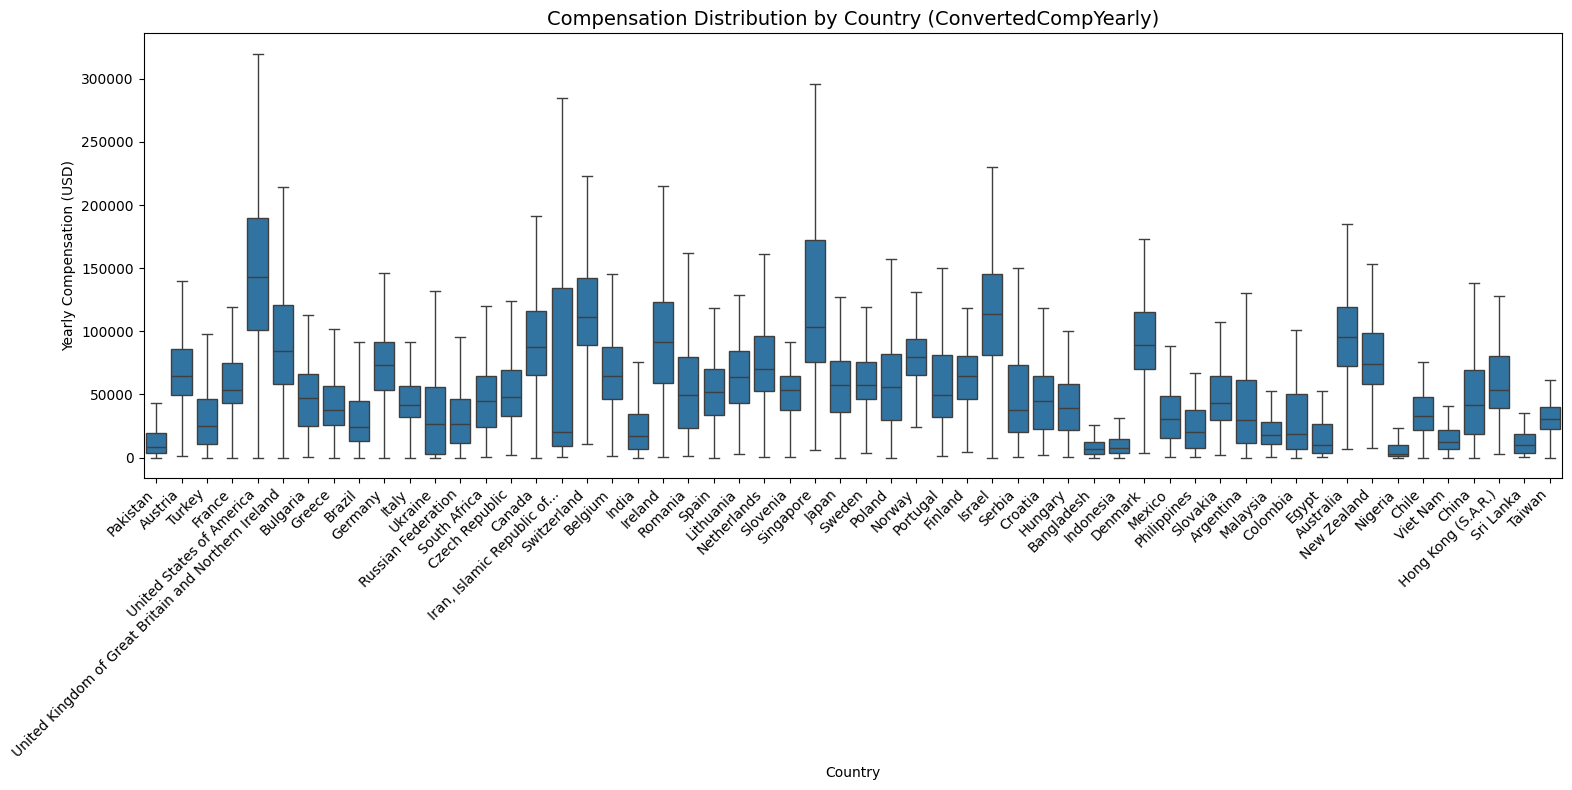

In [9]:
# Keep only rows where compensation and country are not missing
df_country = df[df['ConvertedCompYearly'].notnull() & df['Country'].notnull()]

# Count how many responses each country has
country_counts = df_country['Country'].value_counts()

# Keep only countries with more than 50 responses to avoid very small groups
valid_countries = country_counts[country_counts > 50].index
df_country = df_country[df_country['Country'].isin(valid_countries)]

# Create a box plot to compare compensation distributions by country
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df_country,
    x='Country',
    y='ConvertedCompYearly',
    showfliers=False  # Hide extreme outliers so the country comparison stays readable
)

# Rotate country names and add chart labels
plt.xticks(rotation=45, ha='right')
plt.title('Compensation Distribution by Country (ConvertedCompYearly)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Yearly Compensation (USD)')
plt.tight_layout()

# Display the chart
plt.show()

## Step 6: Remove outliers from the dataset

Create a new dataframe by removing outliers from `ConvertedCompYearly` for a refined correlation analysis.

In [10]:
# Calculate Q1 and Q3 for yearly compensation
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# Calculate the interquartile range
IQR = Q3 - Q1

# Define the lower and upper outlier limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a new dataframe without compensation outliers
df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

# Display the shape of the refined dataset
df_no_outliers.shape

(22457, 114)

## Step 7: Find correlations between key variables

Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`, then visualize them with a heatmap.

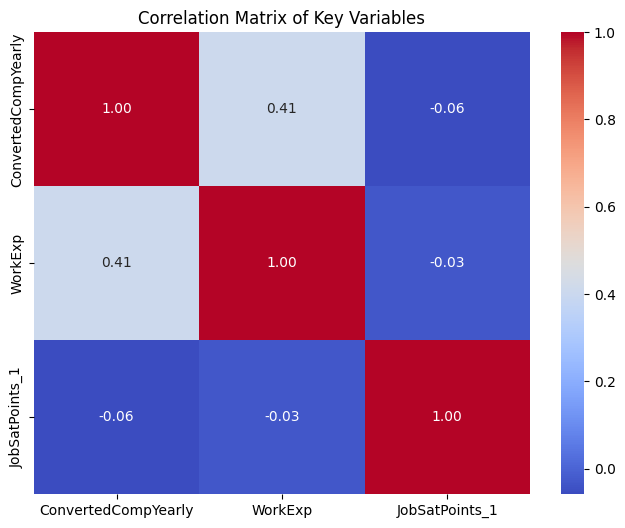

In [11]:
# Select the relevant columns from the dataset without outliers
corr_data = df_no_outliers[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']]

# Calculate the correlation matrix
corr_matrix = corr_data.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

# Add chart title and display the heatmap
plt.title('Correlation Matrix of Key Variables')
plt.show()

## Step 8: Create scatter plots for correlations

Create scatter plots to examine specific relationships between compensation and work experience, and between compensation and job satisfaction.

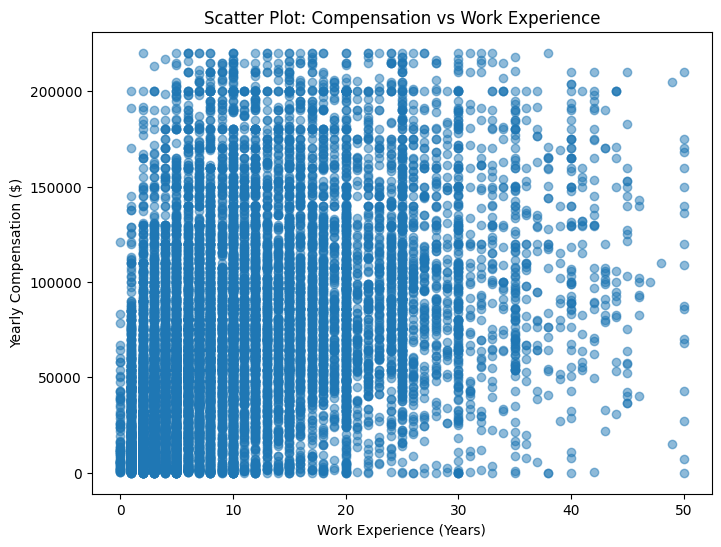

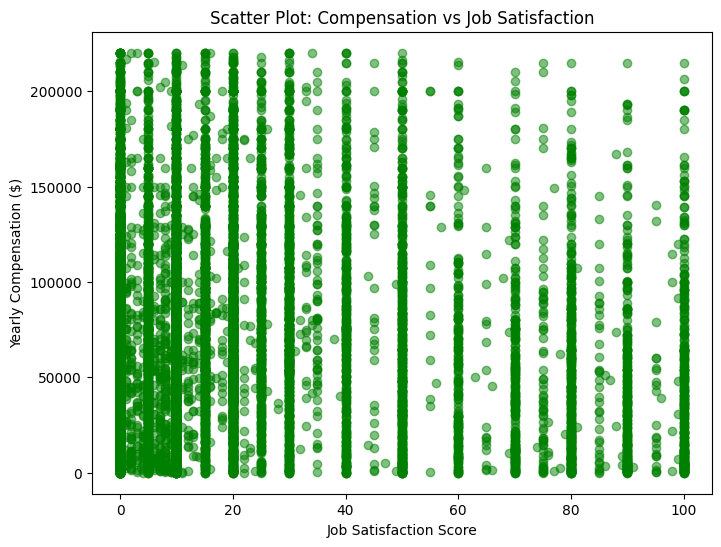

In [12]:
# Scatter plot: ConvertedCompYearly vs WorkExp
plt.figure(figsize=(8, 6))
plt.scatter(
    df_no_outliers['WorkExp'],
    df_no_outliers['ConvertedCompYearly'],
    alpha=0.5
)
plt.xlabel('Work Experience (Years)')
plt.ylabel('Yearly Compensation ($)')
plt.title('Scatter Plot: Compensation vs Work Experience')
plt.show()

# Scatter plot: ConvertedCompYearly vs JobSatPoints_1
plt.figure(figsize=(8, 6))
plt.scatter(
    df_no_outliers['JobSatPoints_1'],
    df_no_outliers['ConvertedCompYearly'],
    alpha=0.5,
    color='green'
)
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Yearly Compensation ($)')
plt.title('Scatter Plot: Compensation vs Job Satisfaction')
plt.show()

## Summary

In this notebook, I practiced:

- examining yearly compensation distribution with histograms and box plots
- comparing compensation distributions across countries
- removing outliers from yearly compensation data
- calculating correlations between compensation, work experience, and job satisfaction
- visualizing relationships with a heatmap and scatter plots